Task 1: Exploratory Data Analysis (EDA):
1.	Load the dataset and perform basic data exploration.
2.	Examine the distribution of features using histograms, box plots, or density plots.
3.	Investigate correlations between features to understand relationships within the data.


In [135]:
# Load dataset
import pandas as pd
df=pd.read_csv('/content/wine.csv')
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [136]:
df.shape

(178, 14)

In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [138]:
# eda
# cheack for missimg values
df.isnull().sum()

,0
Type,0
Alcohol,0
Malic,0
Ash,0
Alcalinity,0
Magnesium,0
Phenols,0
Flavanoids,0
Nonflavanoids,0
Proanthocyanins,0


In [139]:
# checking for duplicates
df.duplicated().any()

False

<Axes: >

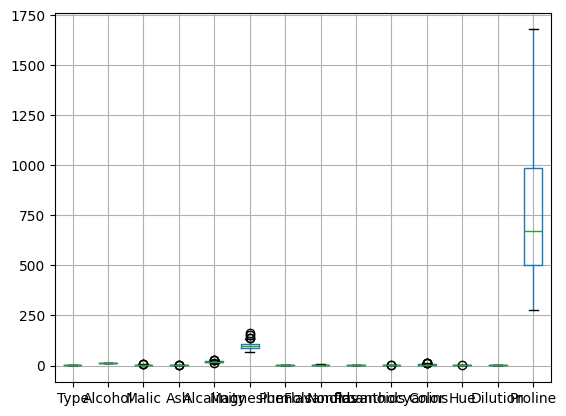

In [140]:
# check for outliers
df.boxplot()

<Axes: ylabel='Count'>

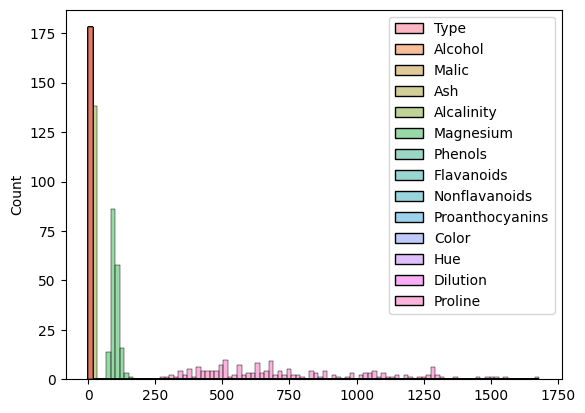

In [141]:
# visualize data distribution
import seaborn as sns
sns.histplot(data=df,bins=100)

<Axes: >

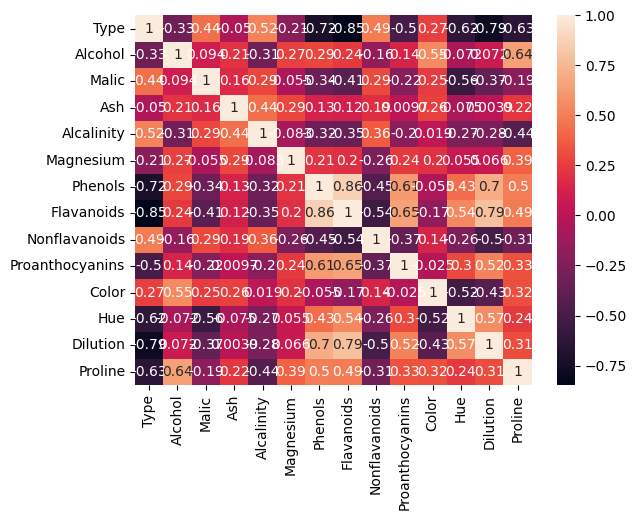

In [142]:
# correlation
corr=df.corr()
sns.heatmap(corr,annot=True)

Task 2: Dimensionality Reduction with PCA:
1.	Standardize the features to ensure they have a mean of 0 and a standard deviation of Implement PCA to reduce the dimensionality of the dataset.
2.	Determine the optimal number of principal components using techniques like scree plot or cumulative explained variance.
3.	Transform the original dataset into the principal components.


In [143]:
# target is price
target=df['Type']

# the rest all are features
features=df.drop(columns='Type')

In [144]:
target.unique()

array([1, 2, 3])

In [145]:
# standardization
from sklearn.preprocessing import StandardScaler
sta_sca=StandardScaler()
features=pd.DataFrame(sta_sca.fit_transform(features),columns=sta_sca.get_feature_names_out(features.columns))
features.head()

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


In [146]:
# determining the optimal principal components
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

In [147]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(features,target,train_size=0.75,random_state=100)

In [148]:
pca=PCA()

In [149]:
pca.fit(x_train)
pca.fit(x_test)

PCA()

In [150]:
x_train_new=pca.transform(x_train)
x_test_new=pca.transform(x_test)

In [151]:
explained_ratio=pca.explained_variance_ratio_

In [152]:
import numpy as np
cumulative_variance = np.cumsum(explained_ratio)
cumulative_variance

array([0.37671158, 0.56576027, 0.69145271, 0.77661057, 0.83459638,
       0.88050135, 0.92419366, 0.94714823, 0.96476865, 0.97737931,
       0.98806203, 0.99458751, 1.        ])

In [153]:
optimal_pc=np.argmax(cumulative_variance >= 0.95 )+1
print(f"optimal_pc:{optimal_pc}")

optimal_pc:9


In [154]:
# transform the original dataset to principal components
pca1=PCA(n_components=9)

In [155]:
pca1.fit(x_train)
pca1.fit(x_test)

PCA(n_components=9)

In [156]:
x_train_new1=pca1.transform(x_train)
x_test_new1=pca1.transform(x_test)

In [157]:
log_model=LogisticRegression(multi_class='ovr')

In [158]:
log_model.fit(x_train_new1,y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='ovr')

In [159]:
y_pred=log_model.predict(x_test_new1)

In [160]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9777777777777777

Task 3: Clustering with Original Data:
1.	Apply a clustering algorithm (e.g., K-means) to the original dataset.
2.	Visualize the clustering results using appropriate plots.
3.	Evaluate the clustering performance using metrics such as silhouette score or Davies–Bouldin index.


In [161]:
# define KMeans
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [162]:
kmeans=KMeans(n_clusters=3)

In [163]:
kmeans.fit(features)

KMeans(n_clusters=3)

In [164]:
np.unique(kmeans.labels_)

array([0, 1, 2], dtype=int32)

In [165]:
silhouette_score(features,kmeans.labels_)

0.2844212860533542

Task 4: Clustering with PCA Data:
1.	Apply the same clustering algorithm to the PCA-transformed dataset.
2.	Visualize the clustering results obtained from PCA-transformed data.
3.	Compare the clustering results from PCA-transformed data with those from the original dataset.


In [166]:
from sklearn.decomposition import PCA

In [167]:
pca=PCA(n_components=2)

In [168]:
pca.fit(features)

PCA(n_components=2)

In [169]:
features_new=pca.transform(features)

In [170]:
kmeans1=KMeans(n_clusters=3)

In [171]:
kmeans1.fit(features_new)

KMeans(n_clusters=3)

In [172]:
silhouette_score(features_new,kmeans1.labels_)

0.5609305721582905

In [173]:
df2=pd.DataFrame(features_new)
df2.head()

,0,1
0,3.316751,1.443463
1,2.209465,-0.333393
2,2.516740,1.031151
3,3.757066,2.756372
4,1.008908,0.869831


In [174]:
df2=df2.rename(columns={0:'pca1',1:'pca2'})
df2.head()

,pca1,pca2
0,3.316751,1.443463
1,2.209465,-0.333393
2,2.516740,1.031151
3,3.757066,2.756372
4,1.008908,0.869831


In [175]:
df2['clusters']=kmeans1.labels_

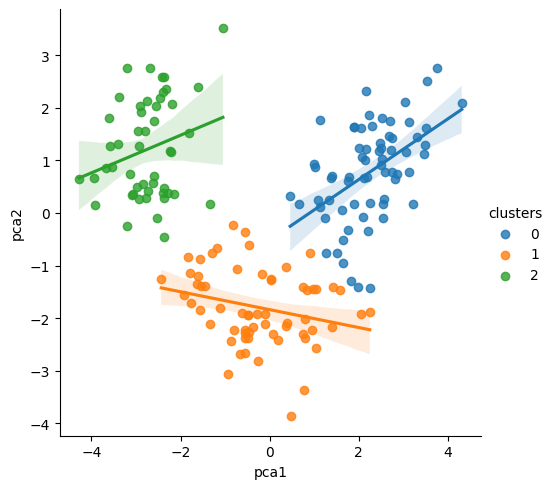

In [176]:
sns.lmplot(data=df2,x='pca1',y='pca2',hue='clusters')

Task 5: Comparison and Analysis:
1.	Compare the clustering results obtained from the original dataset and PCA-transformed data.
2.	Discuss any similarities or differences observed in the clustering results.
3.	Reflect on the impact of dimensionality reduction on clustering performance.
4.	Analyze the trade-offs between using PCA and clustering directly on the original dataset.


In [177]:
'''
1. The performance is better in PCA transformed data compared to original data.


2. In original data, the features are not compressed but in PCA transformed data,the
features are compressed to 2 features.


3. The impact of dimensionality redution on clustering performance is that instead of using the
multiple different features ,providing only certain number of componenets which is combined of all the features gives the
better performance and time taken is also less.


4. By using original data
----- may be noisy data is there
----- contain all the information
----- time taken for computation is high
  By using PCA data
  ----- reduce dimensionality
  ----- may lead to lose some important information
  ----- faster computation
  '''

'\n1. The performance is better in PCA transformed data compared to original data.\n\n\n2. In original data, the features are not compressed but in PCA transformed data,the \nfeatures are compressed to 2 features.\n\n\n3. The impact of dimensionality redution on clustering performance is that instead of using the \nmultiple different features ,providing only certain number of componenets which is combined of all the features gives the \nbetter performance and time taken is also less.\n\n\n4. By using original data\n----- may be noisy data is there\n----- contain all the information\n----- time taken for computation is high\n  By using PCA data\n  ----- reduce dimensionality\n  ----- may lead to lose some important information\n  ----- faster computation\n  '

Task 6: Conclusion and Insights

1.	Summarize the key findings and insights from the assignment.
2.	Discuss the practical implications of using PCA and clustering in data analysis.
3.	Provide recommendations for when to use each technique based on the analysis conducted.


In [178]:
'''
1. The key findings:
 ---- Clustering with original data may suffer with noisy data and high dimensionality.
 ---- Clustering with PCA data may not suffer with high dimensionality issue.


 2. The practical implications:
 ----- Improved Computational Efficiency
 ----- Better Cluster Separation
 ----- Loss of Interpretability


 3.Recommendations:
 ----- for high dimensional data and highly correlated features pca can be sutiable
 ----- for low dimensional data pca is not suitable.
 '''

'\n1. The key findings:\n ---- Clustering with original data may suffer with noisy data and high dimensionality.\n ---- Clustering with PCA data may not suffer with high dimensionality issue.\n\n\n 2. The practical implications:\n ----- Improved Computational Efficiency\n ----- Better Cluster Separation\n ----- Loss of Interpretability\n\n\n 3.Recommendations:\n ----- for high dimensional data and highly correlated features pca can be sutiable\n ----- for low dimensional data pca is not suitable.\n '